In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

#### Problem Definition and Dataset Preview
This dataset comprises 150 samples across 3 iris species (Iris-setosa, Iris-versicolor, Iris-virginica) with 50 samples per species. Each sample has 4 continuous features: SepalLengthCm, SepalWidthCm, PetalLengthCm, and PetalWidthCm. The goal is to build a classification model to accurately predict iris species based on these floral measurements.


In [2]:
iris_df = pd.read_csv("Iris.csv")
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


The dataset is clean with no missing values.

In [4]:
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
iris_df["Species"].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [6]:
iris_df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

#### Data Visualization

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

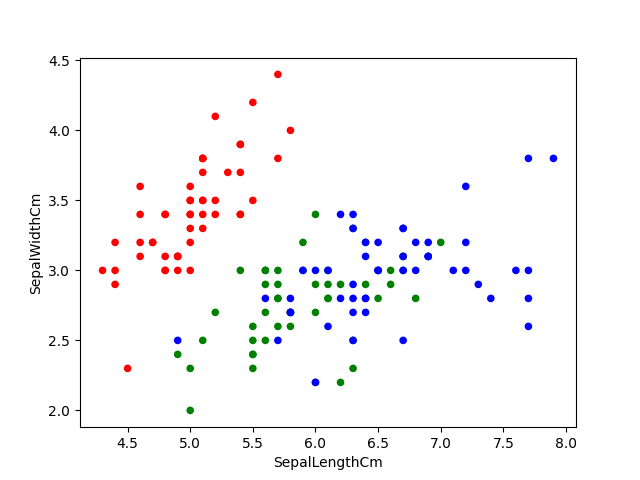

In [8]:
# Color mapping for species in the scatter plot
color_map = {
    "Iris-setosa": "red",
    "Iris-versicolor": "green",
    "Iris-virginica": "blue",   
}

# Example: Scatter plot of Sepal Length vs Sepal Width colored by species
iris_df.plot(kind="scatter", x="SepalLengthCm", y="SepalWidthCm", c=iris_df["Species"].map(color_map))

Now, let’s visualize all pairwise relationships between features using a pairplot. The diagonal density plots provide a clear view of how each iris species is distributed for each feature.

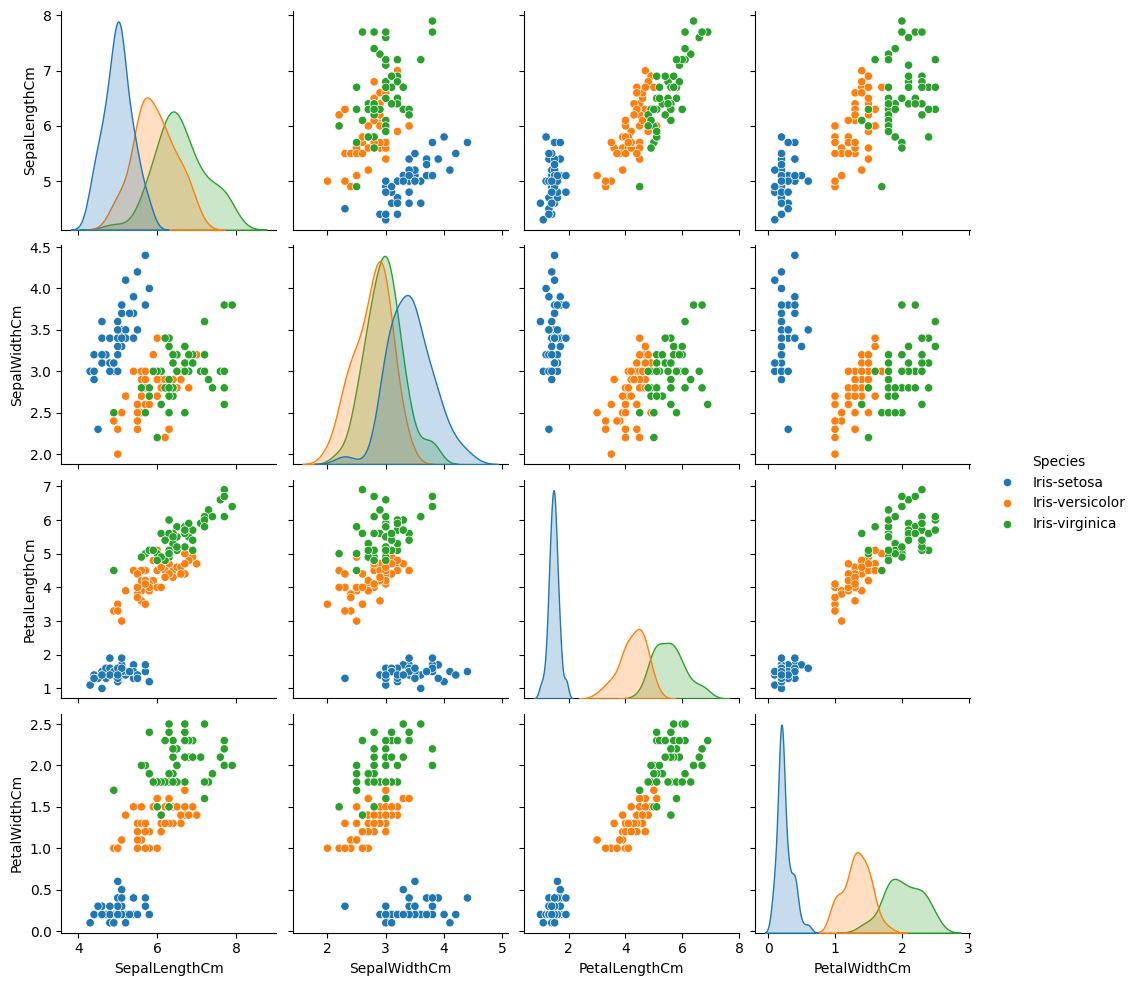

In [33]:
# Pairplot to visualize all relationships between features colored by species
sns.pairplot(
    iris_df,
    hue="Species",
    vars=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
    diag_kind="kde",
)

As it can be seen from the pairplots iris-setosa is linearly separable compared to other species. This suggests simple linear models (logistic regression, SVM) will perform well at classifying setosa. Versicolor and virginica show overlap, requiring more complex decision boundaries.

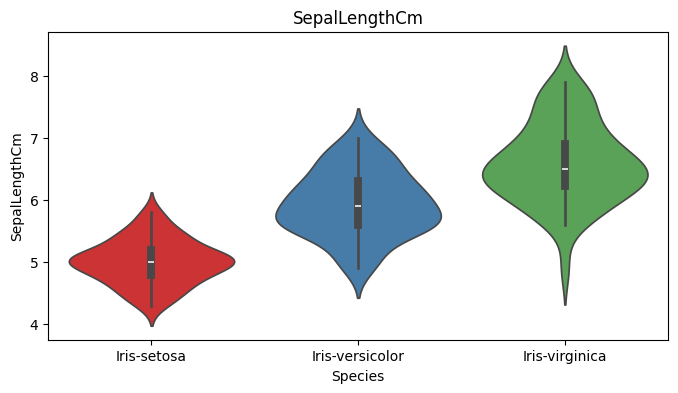

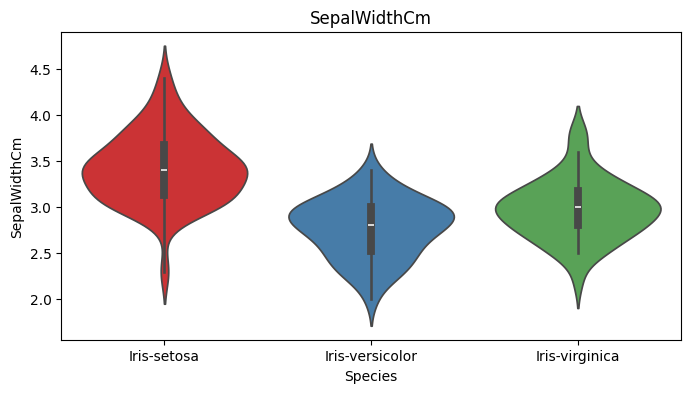

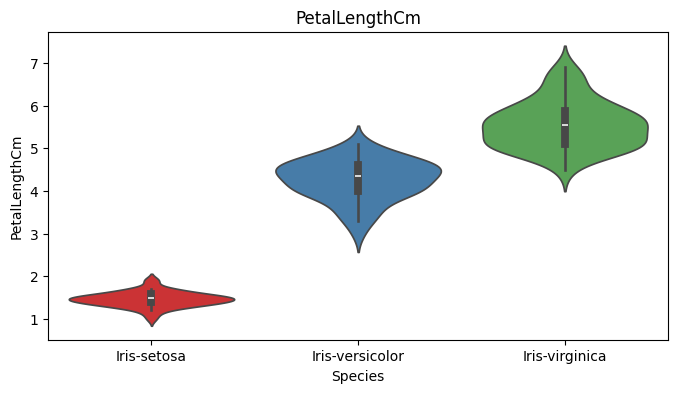

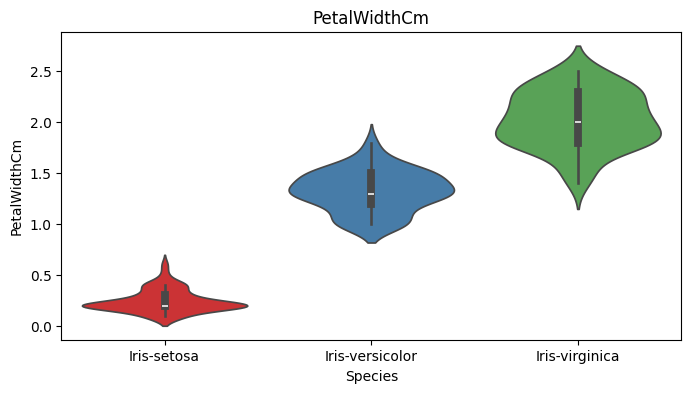

In [34]:
# Violin plots to visualize distribution shapes and densities
for column in ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]:
    plt.figure(figsize=(8, 4))
    sns.violinplot(x="Species", y=column, hue="Species", data=iris_df, palette="Set1")
    plt.title(f"{column}")
    plt.xlabel("Species")
    plt.ylabel(column)
    plt.show()

From the boxplots of PetalWidthCm and PetalLengthCm, Iris-setosa is clearly separable using simple thresholds (e.g., PetalLengthCm < 2.5 and PetalWidthCm < 0.8), so tree-based models should perform strongly. Versicolor and virginica are also mostly separable: their IQRs (inner 50%) are largely distinct, with overlap mainly in boundary regions (approximately versicolor Q3 and virginica Q1). Overall, petal features separate classes better than sepal features, so feature selection using only petal features might be reasonable to test for simpler models and potentially better generalization.We can check this idea later.

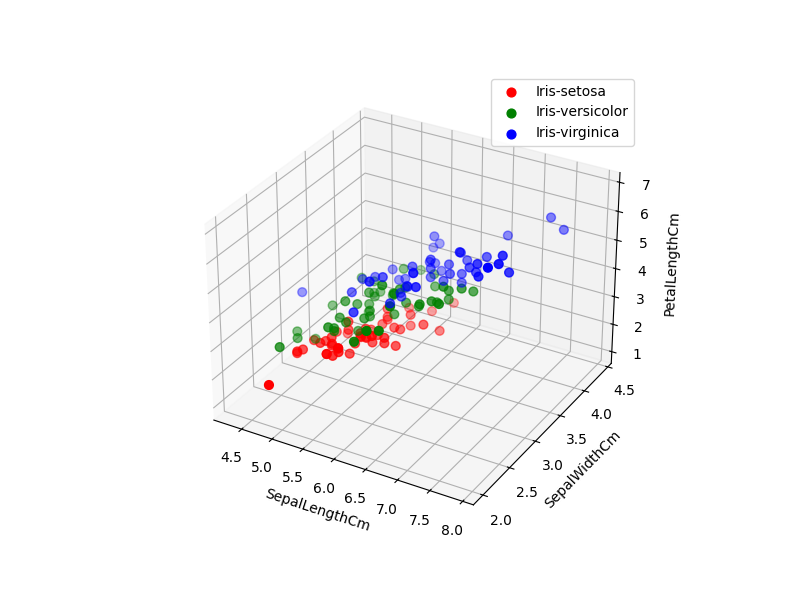

In [28]:
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D  

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

for sp, color in color_map.items():
    d = iris_df[iris_df["Species"] == sp]
    ax.scatter(
        d["SepalLengthCm"], d["SepalWidthCm"], d["PetalLengthCm"],
        c=color, label=sp, s=40
    )

ax.set_xlabel("SepalLengthCm")
ax.set_ylabel("SepalWidthCm")
ax.set_zlabel("PetalLengthCm")
ax.legend()
plt.show()

3D visualization of the dataset. There are four possible three-feature combinations, and we can inspect each by changing the feature axes.

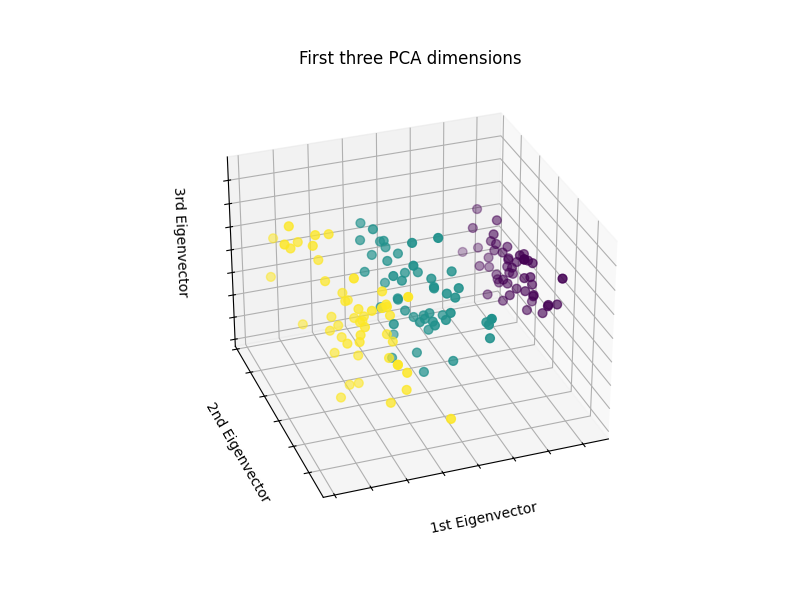

In [35]:
%matplotlib widget
import mpl_toolkits.mplot3d 
from sklearn.decomposition import PCA

feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X_reduced = PCA(n_components=3).fit_transform(iris_df[feature_cols].values)
target = iris_df["Species"].astype("category").cat.codes 

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=target, s=40)

ax.set_title("First three PCA dimensions")
ax.set_xlabel("1st Eigenvector")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("2nd Eigenvector")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("3rd Eigenvector")
ax.zaxis.set_ticklabels([])

plt.show()

Let’s apply a Principal Component Analysis (PCA) to the iris dataset and then plot the irises across the first three PCA dimensions. PCA will create 3 new features that are a linear combination of the 4 original features.

Text(0.5, 1.0, 'Feature Correlation Heatmap')

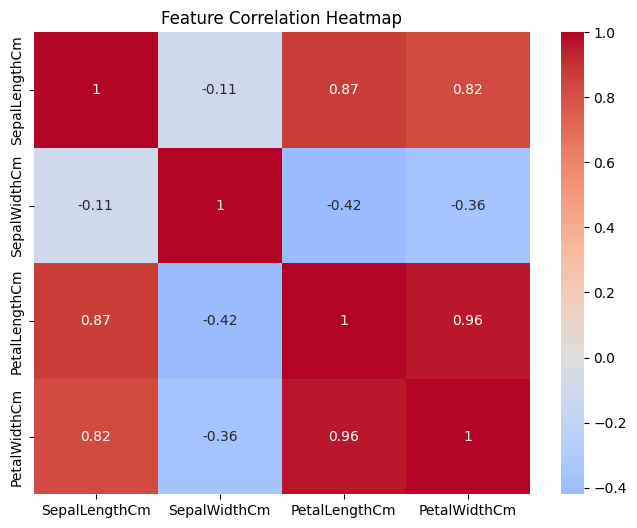

In [37]:
# Correlation heatmap to visualize relationships between features

%matplotlib inline
plt.figure(figsize=(8,6))
sns.heatmap(iris_df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].corr(), 
            annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")

Looking at the correlation matrix these can be concluded:
- PetalLengthCm & PetalWidthCm are highly correlated (≈ 0.96), hence they may carry redundant information
- SepalWidthCm has weak linear correlation with other features, hence it provides unique, independent information
- SepalLengthCm shows moderate correlation with petal features

Feature Engineering Hypothesis:
Since petal width and length are highly correlated, we can drop one of them to avoid the repition of the similar information. We can test a subset using only uncorrelated/independent features: 
- **Full Model:** All 4 features (baseline)
- **Subset 1:** Drop PetalWidthCm, keep the other 3 features (SepalLengthCm, SepalWidthCm, PetalLengthCm) — removes redundancy while keeping most information
- **Subset 2:** PetalLengthCm + SepalWidthCm (one petal feature + independent sepal feature) — extreme dimensionality reduction

This will help us understand:
- If we can reduce dimensionality while maintaining model performance
- Whether dropping the highly correlated PetalWidthCm significantly impacts accuracy
- Whether the minimal 2-feature model is competitive despite simplicity

#### Data Preprocessing

In the first part, we will train baseline machine learning models using all features. Later, we will train the same models on feature subsets to compare performance. Before that, we need to remove the 'Id' column and label-encode the target variable, 'Species'.

In [14]:
# Keep iris_df intact for visualization — all preprocessing happens on the copy
iris_processed = iris_df.copy()
iris_processed.drop(['Id'], axis=1, inplace=True)

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_processed["Species"] = le.fit_transform(iris_processed["Species"])
iris_processed.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Although the continous features are all in valid ranges, scaling is still required, especially for distance-based models like KNN—because feature ranges and variances differ.

In [16]:
from sklearn.preprocessing import StandardScaler

X = iris_processed.drop("Species", axis=1)
y = iris_processed["Species"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


#### Model Training

Let’s split our dataset into train and test subsets with 80/20 ratio and evaluate the accuracies of different ML algorithms.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=43)

In [18]:
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

model = LogisticRegression()
model.fit(X_train, y_train)
prediction=model.predict(X_test)
print('The accuracy of the Logistic Regression is',metrics.accuracy_score(prediction,y_test))

The accuracy of the Logistic Regression is 0.9666666666666667


In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
prediction=model.predict(X_test)
print('The accuracy of the Decision Tree is',metrics.accuracy_score(prediction,y_test))

The accuracy of the Decision Tree is 0.9


In [20]:
from sklearn.neighbors import KNeighborsClassifier

acc = []
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    acc.append(metrics.accuracy_score(pred_k, y_test))
print(acc)
print('The accuracy of the K-Nearest Neighbors is achieved with k=' + str(np.argmax(acc)+1) + ', max accuracy:', max(acc))

[0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667]
The accuracy of the K-Nearest Neighbors is achieved with k=1, max accuracy: 0.9666666666666667


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_prediction = rf_model.predict(X_test)
print('The accuracy of the Random Forest is', metrics.accuracy_score(rf_prediction, y_test))

The accuracy of the Random Forest is 0.9333333333333333


In [22]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
gnb_prediction = gnb_model.predict(X_test)
print('The accuracy of the Gaussian Naive Bayes is', metrics.accuracy_score(gnb_prediction, y_test))

The accuracy of the Gaussian Naive Bayes is 0.9666666666666667


##### K-fold Cross Validation
Instead of relying on one single train/test split, we perform cross-validation because evaluating on only one random test set can be unstable and biased.

**Procedure:**
1. Set aside 20% of the dataset as a final holdout test set (kept untouched during tuning).
2. Use the remaining 80% as the training portion.
3. Run Stratified 5-fold cross-validation on that 80% training portion.
4. Compute fold accuracies and their average CV performance.
5. If average CV performance is satisfactory, train the final model on the full 80% training set.
6. Evaluate once on the untouched 20% holdout test set to report final generalization performance.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train_holdout, X_test_holdout, y_train_holdout, y_test_holdout = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
skf_holdout = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_holdout = LogisticRegression(max_iter=1000, random_state=42)
cv_scores_holdout = cross_val_score(log_reg_holdout, X_train_holdout, y_train_holdout, cv=skf_holdout, scoring="accuracy")
log_reg_holdout.fit(X_train_holdout, y_train_holdout)
lr_test_acc = accuracy_score(y_test_holdout, log_reg_holdout.predict(X_test_holdout))

print("Logistic Regression fold accuracies:", np.round(cv_scores_holdout, 4))
print("Logistic Regression mean CV accuracy:", round(cv_scores_holdout.mean(), 4), f"(±{cv_scores_holdout.std():.4f})")
print("Logistic Regression holdout test accuracy:", round(lr_test_acc, 4))

Fold accuracies: [0.9583 1.     0.9583 0.9583 0.9167]
Mean CV accuracy: 0.9583
Final holdout test accuracy: 0.9333


Now we evaluate SVM with the same setup: 5-fold cross-validation on the 80% training split, then one final evaluation on the untouched 20% holdout test set.

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_cv_scores = cross_val_score(svm_model, X_train_holdout, y_train_holdout, cv=skf_holdout, scoring="accuracy")
svm_model.fit(X_train_holdout, y_train_holdout)
svm_test_acc = accuracy_score(y_test_holdout, svm_model.predict(X_test_holdout))

print("SVM fold accuracies:", np.round(svm_cv_scores, 4))
print("SVM mean CV accuracy:", round(svm_cv_scores.mean(), 4), f"(±{svm_cv_scores.std():.4f})")
print("SVM holdout test accuracy:", round(svm_test_acc, 4))

SVM fold accuracies: [0.9583 1.     0.9583 0.9583 0.9583]
SVM mean CV accuracy: 0.9667
SVM final holdout test accuracy: 0.9667


In [39]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_cv_scores = cross_val_score(dt_model, X_train_holdout, y_train_holdout, cv=skf_holdout, scoring="accuracy")
dt_model.fit(X_train_holdout, y_train_holdout)
dt_test_acc = accuracy_score(y_test_holdout, dt_model.predict(X_test_holdout))

print("Decision Tree fold accuracies:", np.round(dt_cv_scores, 4))
print("Decision Tree mean CV accuracy:", round(dt_cv_scores.mean(), 4), f"(±{dt_cv_scores.std():.4f})")
print("Decision Tree holdout test accuracy:", round(dt_test_acc, 4))

Decision Tree fold accuracies: [0.9583 0.9583 0.9583 0.9583 0.9167]
Decision Tree mean CV accuracy: 0.95 (±0.0167)
Decision Tree holdout test accuracy: 0.9


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=2)
knn_cv_scores = cross_val_score(knn_model, X_train_holdout, y_train_holdout, cv=skf_holdout, scoring="accuracy")
knn_model.fit(X_train_holdout, y_train_holdout)
knn_test_acc = accuracy_score(y_test_holdout, knn_model.predict(X_test_holdout))

print("KNN fold accuracies:", np.round(knn_cv_scores, 4))
print("KNN mean CV accuracy:", round(knn_cv_scores.mean(), 4), f"(±{knn_cv_scores.std():.4f})")
print("KNN holdout test accuracy:", round(knn_test_acc, 4))

KNN fold accuracies: [0.9583 1.     0.9583 0.9167 0.9167]
KNN mean CV accuracy: 0.95 (±0.0312)
KNN holdout test accuracy: 0.9333


In [42]:
from sklearn.naive_bayes import GaussianNB

gnb_cv_model = GaussianNB()
gnb_cv_scores = cross_val_score(gnb_cv_model, X_train_holdout, y_train_holdout, cv=skf_holdout, scoring="accuracy")
gnb_cv_model.fit(X_train_holdout, y_train_holdout)
gnb_test_acc = accuracy_score(y_test_holdout, gnb_cv_model.predict(X_test_holdout))

print("Gaussian NB fold accuracies:", np.round(gnb_cv_scores, 4))
print("Gaussian NB mean CV accuracy:", round(gnb_cv_scores.mean(), 4), f"(±{gnb_cv_scores.std():.4f})")
print("Gaussian NB holdout test accuracy:", round(gnb_test_acc, 4))

Gaussian NB fold accuracies: [0.9583 0.9583 0.9583 0.9583 0.9167]
Gaussian NB mean CV accuracy: 0.95 (±0.0167)
Gaussian NB holdout test accuracy: 0.9667


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_cv_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cv_scores = cross_val_score(rf_cv_model, X_train_holdout, y_train_holdout, cv=skf_holdout, scoring="accuracy")
rf_cv_model.fit(X_train_holdout, y_train_holdout)
rf_test_acc = accuracy_score(y_test_holdout, rf_cv_model.predict(X_test_holdout))

print("Random Forest fold accuracies:", np.round(rf_cv_scores, 4))
print("Random Forest mean CV accuracy:", round(rf_cv_scores.mean(), 4), f"(±{rf_cv_scores.std():.4f})")
print("Random Forest holdout test accuracy:", round(rf_test_acc, 4))

Random Forest fold accuracies: [0.9583 1.     0.9583 0.9167 0.9167]
Random Forest mean CV accuracy: 0.95 (±0.0312)
Random Forest holdout test accuracy: 0.9
